In [1]:
import numpy as np
import matplotlib as mt
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import MDAnalysis as mda
import scipy as sc
import scipy.optimize as sco
import scipy.spatial as scp
from tqdm import tqdm
import sklearn as skl
import pickle as pkl

### dist to dist correlation fitting

In [2]:
cog = [
    np.loadtxt(f'bp_cog/r{r}.xvg', comments=['@','#'])[:,1]
    for r in range(8)
]

In [3]:
fd = [
    np.loadtxt(f'../r{r}/HILLS')[:,1][::10]
    for r in range(8)
]

In [4]:
for r in range(8):
    if cog[r].shape[0] > fd[r].shape[0]:
        cog[r] = cog[r][:fd[r].shape[0]]
    elif cog[r].shape[0] < fd[r].shape[0]:
        fd[r] = fd[r][:cog[r].shape[0]]
    #
    print(cog[r].shape, fd[r].shape)

(31991,) (31991,)
(32352,) (32352,)
(32354,) (32354,)
(34010,) (34010,)
(33431,) (33431,)
(34516,) (34516,)
(34482,) (34482,)
(32864,) (32864,)


In [5]:
def linear(x, m, c):
    return x*m + c

params = sco.curve_fit(linear, np.concatenate((fd)), np.concatenate((cog)))[0]
params

array([ 0.98385771, -0.83078786])

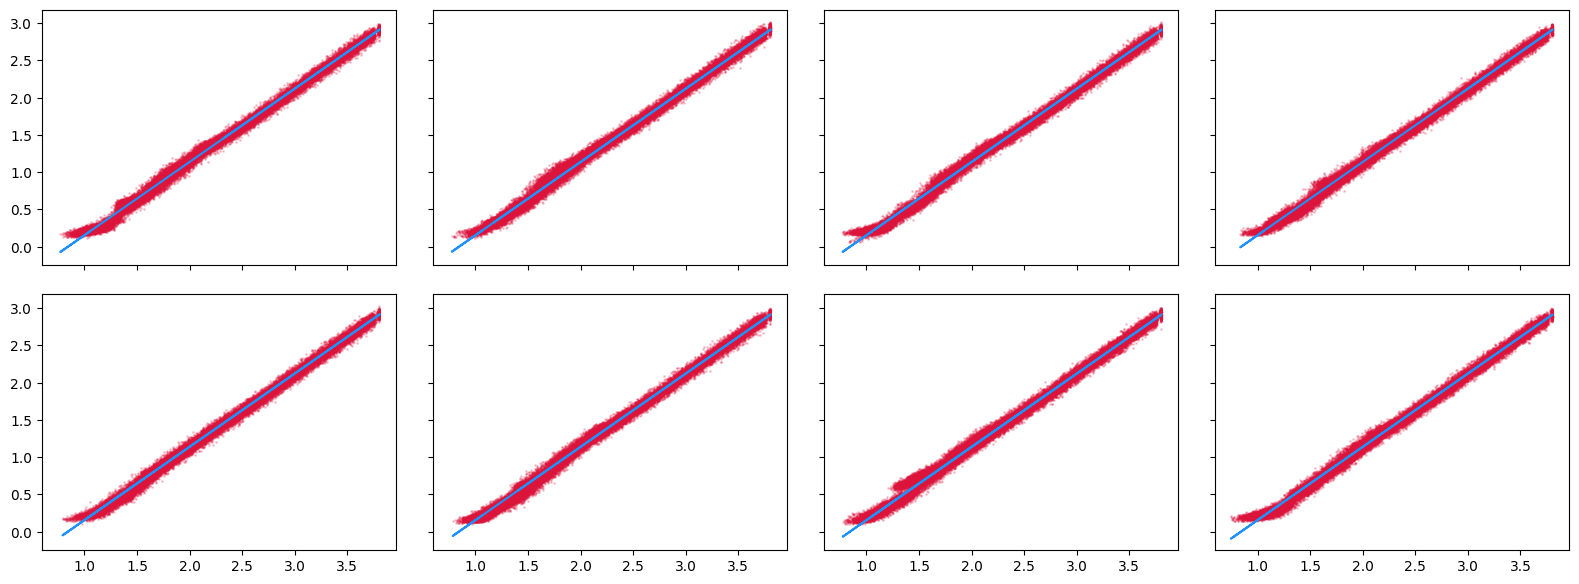

In [6]:
fig, ax = plt.subplots(2,4, figsize=(16,6), sharex=True, sharey=True)
plt.tight_layout()
ax=np.concatenate((ax))
for r in range(8):
    ax[r].scatter(fd[r], cog[r], s=1, alpha=0.2, color='crimson')
    ax[r].plot(fd[r], linear(fd[r], *params), color='dodgerblue')
plt.show()

#### linear model not good at lower values

In [5]:
pmodel = np.poly1d(
    np.polyfit(
        np.concatenate((fd)), np.concatenate((cog)), 5
    )
)

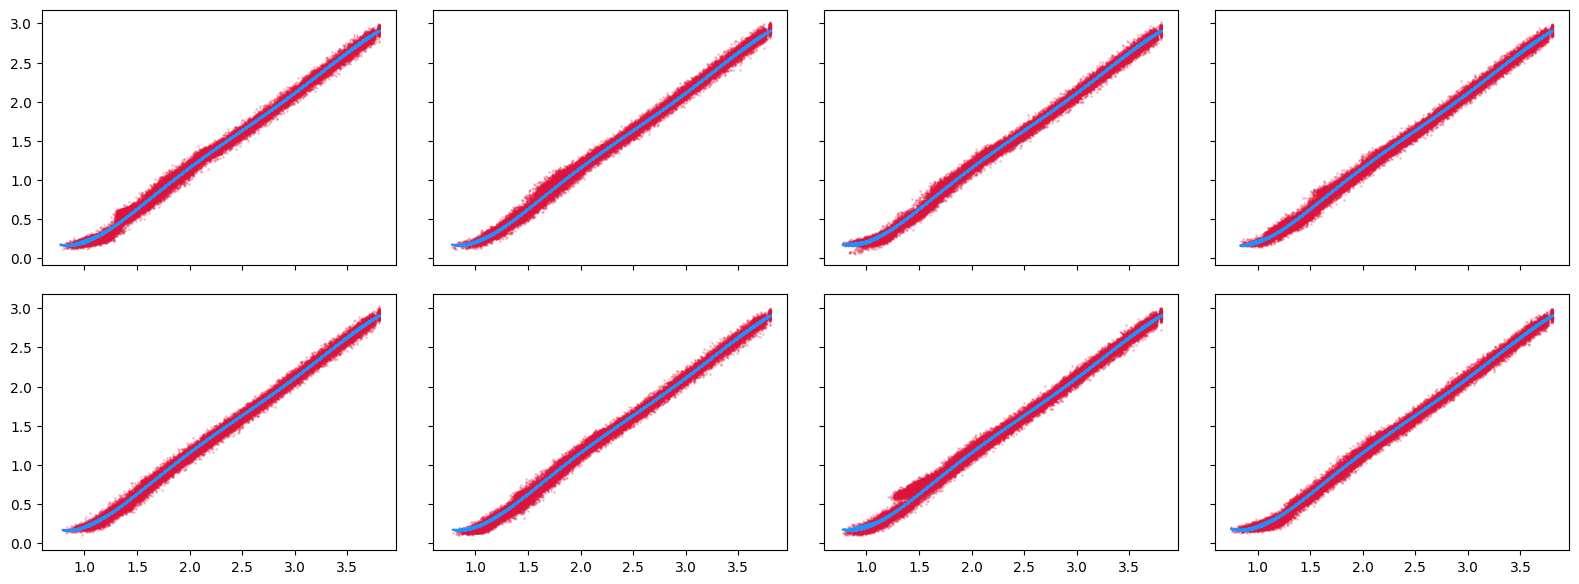

In [6]:
fig, ax = plt.subplots(2,4, figsize=(16,6), sharex=True, sharey=True)
plt.tight_layout()
ax=np.concatenate((ax))
for r in range(8):
    ax[r].scatter(fd[r], cog[r], s=1, alpha=0.2, color='crimson')
    ax[r].plot(fd[r], pmodel(fd[r]), color='dodgerblue')
plt.show()

#### a 5 degree polynomial works

In [7]:
pmodel

poly1d([-0.05886585,  0.72891266, -3.4712057 ,  7.90091612, -7.55800776,
        2.65621756])

### binding events

In [2]:
rmsd = [
    np.loadtxt(f'rmsds/r{r}.xvg', comments=['@','#'])[:,1]
    for r in [0,2,7,14]
]
cog = [
    np.loadtxt(f'bp_cog/r{r}.xvg', comments=['@','#'])[:,1]
    for r in [0,2,7,14]
]
angle = [
    np.loadtxt(f'angle/r{r}.xvg', comments=['@','#'])[:,1]
    for r in [0,2,7,14]
]
times = [
    np.loadtxt(f'bp_cog/r{r}.xvg', comments=['@','#'])[:,0]
    for r in [0,2,7,14]
]

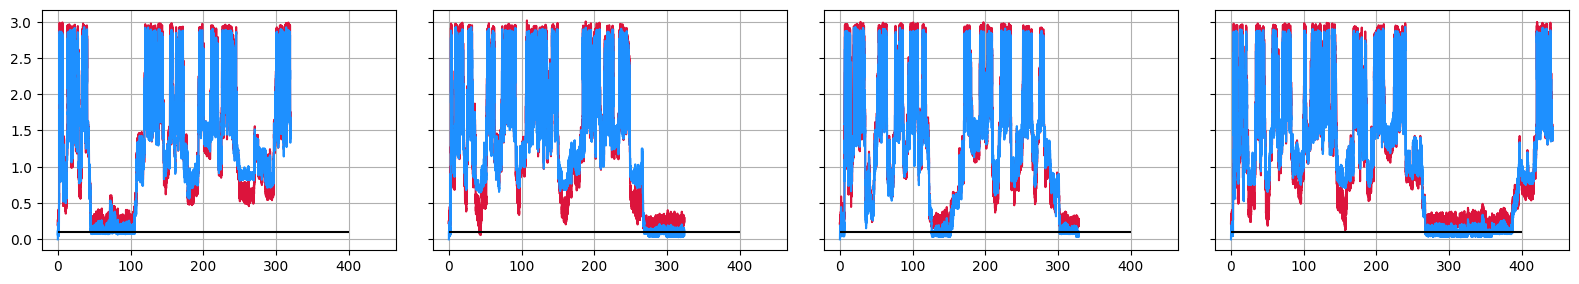

In [9]:
fig, ax = plt.subplots(1,4, figsize=(16,3), sharex=True, sharey=True)
plt.tight_layout()
for r in range(4):
    ax[r].plot(times[r]/1e3, cog[r], color='crimson', )
    ax[r].plot(times[r]/1e3, rmsd[r], color='dodgerblue', alpha=1)
    ax[r].hlines(0.1, 0, 400, color='black')
    ax[r].grid()
plt.show()

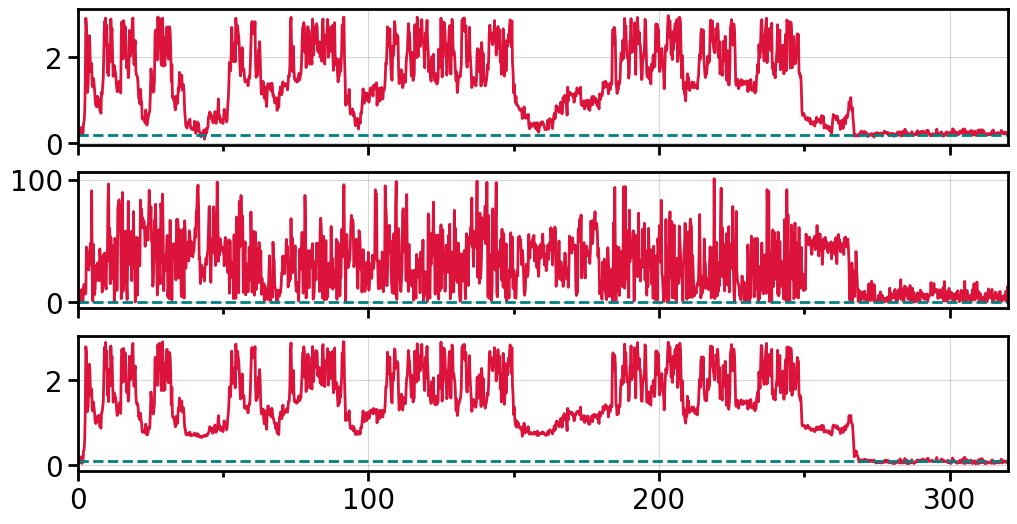

In [41]:
fig,ax = plt.subplots(3,1, figsize=(12,6), sharex=True)
r=1
skip=20
#
ax[0].plot(times[r][::skip]/1e3, cog[r][::skip], color='crimson', lw=2)
ax[0].hlines(0.2, 0,320, linestyle='--', color='teal', lw=2)
#
ax[1].plot(times[r][::skip]/1e3, np.abs(angle[r][::skip]-78), color='crimson', lw=2)
ax[1].hlines(0, 0,320, linestyle='--', color='teal', lw=2)
#
ax[2].plot(times[r][::skip]/1e3, rmsd[r][::skip], color='crimson', lw=2)
ax[2].hlines(0.1, 0,320, linestyle='--', color='teal', lw=2)
#
ax[0].set_xlim(0,320)
ax[0].set_xticks([0,100,200,300])
#
for a in ax: 
    a.grid(alpha=0.5)
    a.tick_params(labelsize=20, length=7, width=2)
    a.xaxis.set_minor_locator(AutoMinorLocator(2))
    a.tick_params(which='minor', length=4, width=2)
    a.spines[:].set_linewidth(2)
#
plt.savefig('saved_ana/cvs1.pdf')
plt.show()

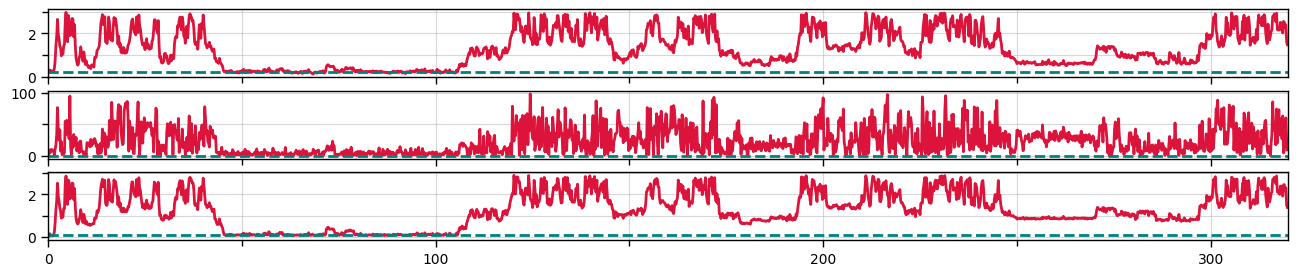

In [5]:
fig,ax = plt.subplots(3,1, figsize=(16,3), sharex=True)
r=0
# r=2
skip=20
#
ax[0].plot(times[r][::skip]/1e3, cog[r][::skip], color='crimson', lw=2)
ax[0].hlines(0.2, 0,320, linestyle='--', color='teal', lw=2)
#
ax[1].plot(times[r][::skip]/1e3, np.abs(angle[r][::skip]-78), color='crimson', lw=2)
ax[1].hlines(0, 0,320, linestyle='--', color='teal', lw=2)
#
ax[2].plot(times[r][::skip]/1e3, rmsd[r][::skip], color='crimson', lw=2)
ax[2].hlines(0.1, 0,320, linestyle='--', color='teal', lw=2)
#
ax[0].set_xlim(0,320)
ax[0].set_xticks([0,100,200,300])
#
for a in ax: 
    a.grid(alpha=0.5, which='both')
    a.tick_params(labelsize=10, length=5, width=1)
    a.xaxis.set_minor_locator(AutoMinorLocator(2))
    a.yaxis.set_minor_locator(AutoMinorLocator(2))
    a.tick_params(which='minor', length=4, width=1)
    a.spines[:].set_linewidth(1)
#
plt.savefig(f'saved_ana/cvs{r}.pdf')
plt.show()

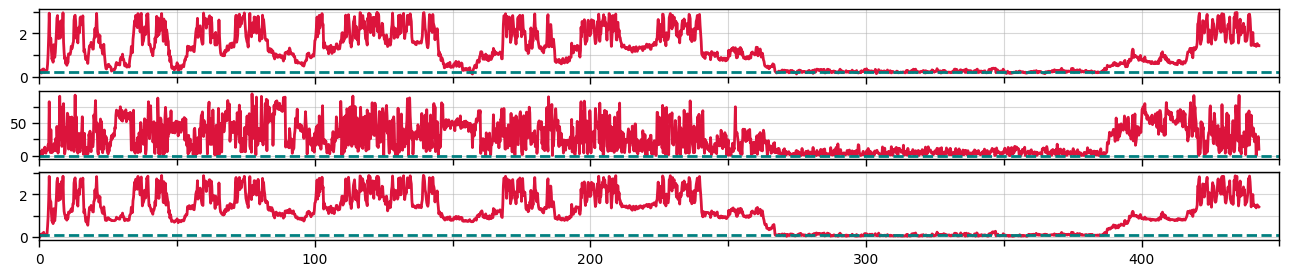

In [6]:
fig,ax = plt.subplots(3,1, figsize=(16,3), sharex=True)
r=3
skip=20
#
ax[0].plot(times[r][::skip]/1e3, cog[r][::skip], color='crimson', lw=2)
ax[0].hlines(0.2, 0,450, linestyle='--', color='teal', lw=2)
#
ax[1].plot(times[r][::skip]/1e3, np.abs(angle[r][::skip]-78), color='crimson', lw=2)
ax[1].hlines(0, 0,450, linestyle='--', color='teal', lw=2)
#
ax[2].plot(times[r][::skip]/1e3, rmsd[r][::skip], color='crimson', lw=2)
ax[2].hlines(0.1, 0,450, linestyle='--', color='teal', lw=2)
#
ax[0].set_xlim(0,450)
ax[0].set_xticks([0,100,200,300,400])
#
for a in ax: 
    a.grid(alpha=0.5, which='both')
    a.tick_params(labelsize=10, length=5, width=1)
    a.xaxis.set_minor_locator(AutoMinorLocator(2))
    a.yaxis.set_minor_locator(AutoMinorLocator(2))
    a.tick_params(which='minor', length=4, width=1)
    a.spines[:].set_linewidth(1)
#
plt.savefig(f'saved_ana/cvs{r}.pdf')
plt.show()

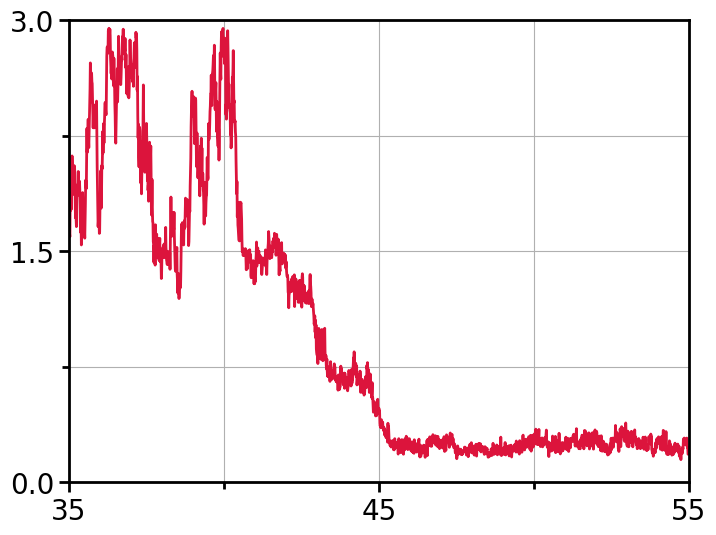

In [19]:
fig,ax = plt.subplots(1, figsize=(8,6))
ax.plot(times[0]/1e3, cog[0], lw=2, color='crimson')
ax.set_xlim(35,55)
ax.set_xticks([35,45,55])
ax.set_ylim(0,3)
ax.set_yticks([0,1.5,3])
ax.tick_params(labelsize=20, length=7, width=2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=5, width=2)
ax.spines[:].set_linewidth(2)
ax.grid(which='both')
#
plt.savefig('saved_ana/zoomed_0.pdf')
plt.show()

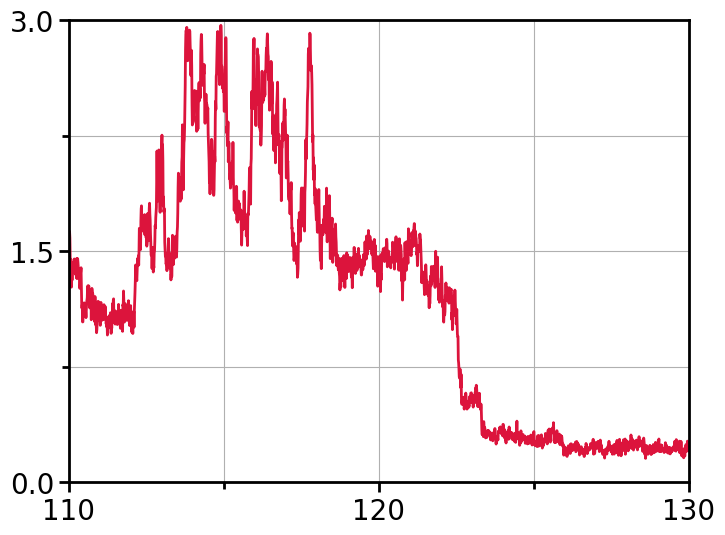

In [16]:
fig,ax = plt.subplots(1, figsize=(8,6))
ax.plot(times[2]/1e3, cog[2], lw=2, color='crimson')
ax.set_xlim(110,130)
ax.set_xticks([110,120,130])
ax.set_ylim(0,3)
ax.set_yticks([0,1.5,3])
ax.tick_params(labelsize=20, length=7, width=2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=5, width=2)
ax.spines[:].set_linewidth(2)
ax.grid(which='both')
#
plt.savefig('saved_ana/zoomed_2.1.pdf')
plt.show()

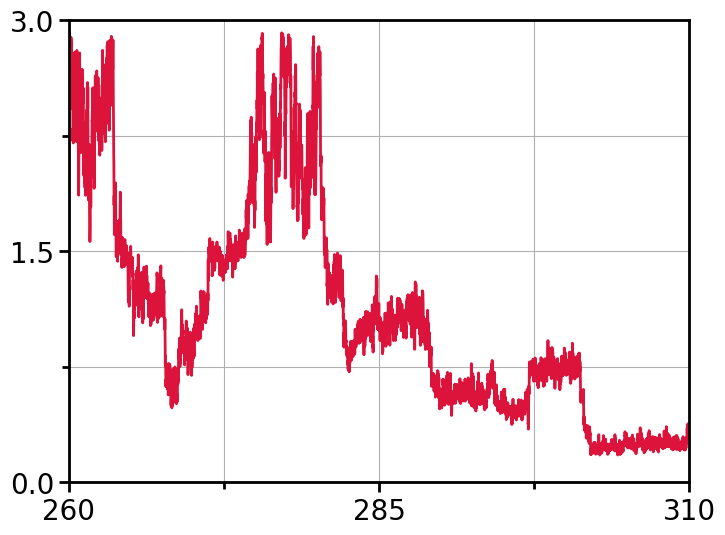

In [13]:
fig,ax = plt.subplots(1, figsize=(8,6))
ax.plot(times[2]/1e3, cog[2], lw=2, color='crimson')
ax.set_xlim(260,310)
ax.set_xticks([260,285,310])
ax.set_ylim(0,3)
ax.set_yticks([0,1.5,3])
ax.tick_params(labelsize=20, length=7, width=2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=5, width=2)
ax.spines[:].set_linewidth(2)
ax.grid(which='both')
#
plt.savefig('saved_ana/zoomed_2.2.pdf')
plt.show()

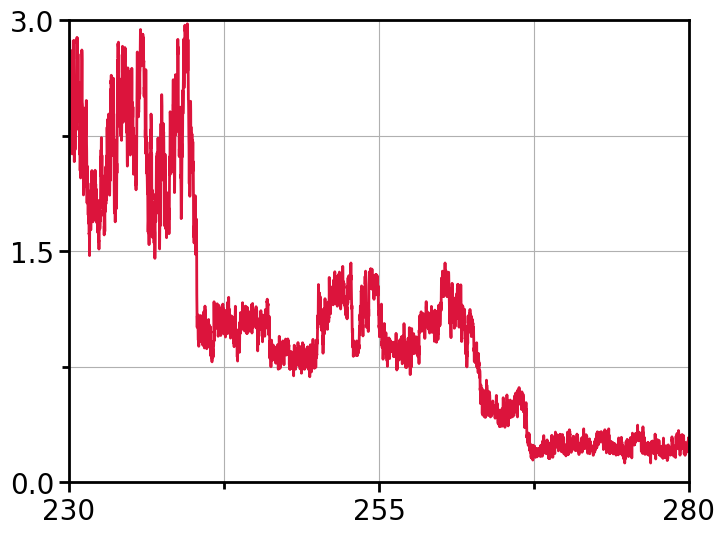

In [22]:
fig,ax = plt.subplots(1, figsize=(8,6))
ax.plot(times[3]/1e3, cog[3], lw=2, color='crimson')
ax.set_xlim(230,280)
ax.set_xticks([230,255,280])
ax.set_ylim(0,3)
ax.set_yticks([0,1.5,3])
ax.tick_params(labelsize=20, length=7, width=2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=5, width=2)
ax.spines[:].set_linewidth(2)
ax.grid(which='both')
#
plt.savefig('saved_ana/zoomed_3.pdf')
plt.show()

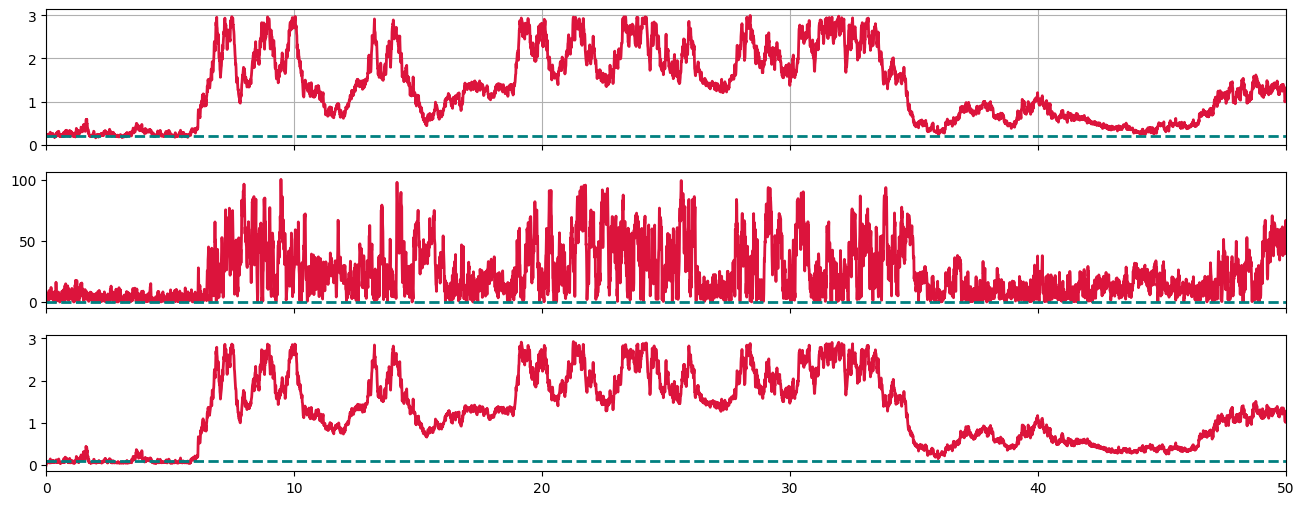

In [17]:
fig,ax = plt.subplots(3,1, figsize=(16,6), sharex=True)
# r=0
r=2
skip=1
#
ax[0].plot(times[r][::skip]/1e3, cog[r][::skip], color='crimson', lw=2)
ax[0].hlines(0.2, 0,320, linestyle='--', color='teal', lw=2)
#
ax[1].plot(times[r][::skip]/1e3, np.abs(angle[r][::skip]-78), color='crimson', lw=2)
ax[1].hlines(0, 0,320, linestyle='--', color='teal', lw=2)
#
ax[2].plot(times[r][::skip]/1e3, rmsd[r][::skip], color='crimson', lw=2)
ax[2].hlines(0.1, 0,320, linestyle='--', color='teal', lw=2)
#
ax[0].set_xlim(0,50)
ax[0].grid()
#
plt.show()

### fes

In [8]:
fes = [
    np.loadtxt(f'sum_fills/r{r}.dat')[:,1]
    for r in [0,2,7,14]
]
cv = np.loadtxt('sum_fills/r0.dat')[:,0]

In [9]:
cv = pmodel(cv)
indi = np.argmin(np.abs(cv-2.0))
fes = [
    (f - f[indi]) * 0.24
    for f in fes
]

In [10]:
fmean = np.mean(fes, axis=0)
fstd = np.std(fes, axis=0)
ferr = fstd/np.sqrt(len(fes))

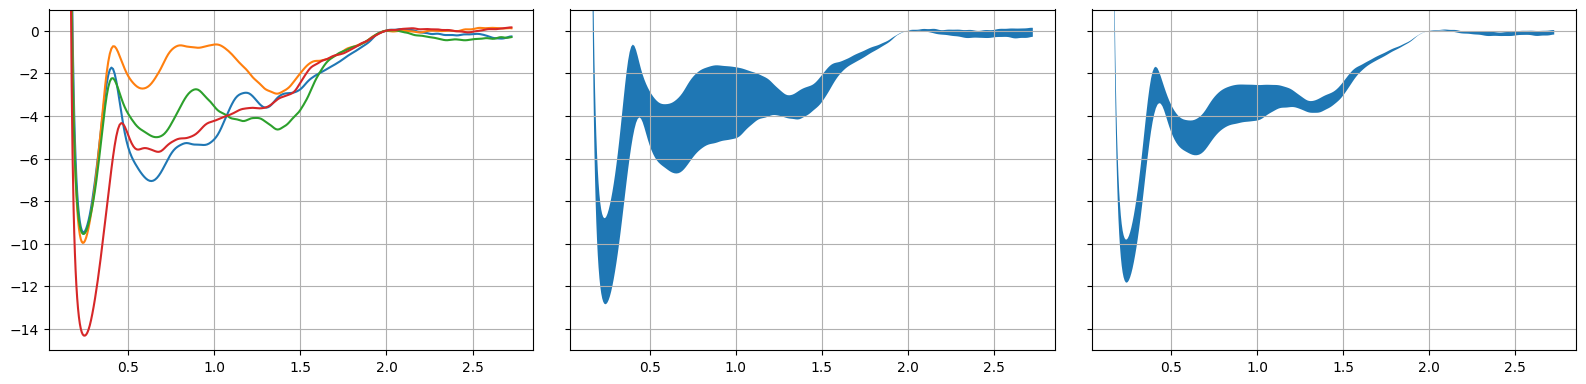

In [14]:
fig,ax=plt.subplots(1,3,figsize=(16,4), sharex=True, sharey=True)
plt.tight_layout()
for f in fes: ax[0].plot(cv, f)
ax[1].fill_between(cv, fmean-fstd, fmean+fstd)
ax[2].fill_between(cv, fmean-ferr, fmean+ferr)
ax[0].set_ylim(-15,1)
for a in ax: a.grid()
plt.show()

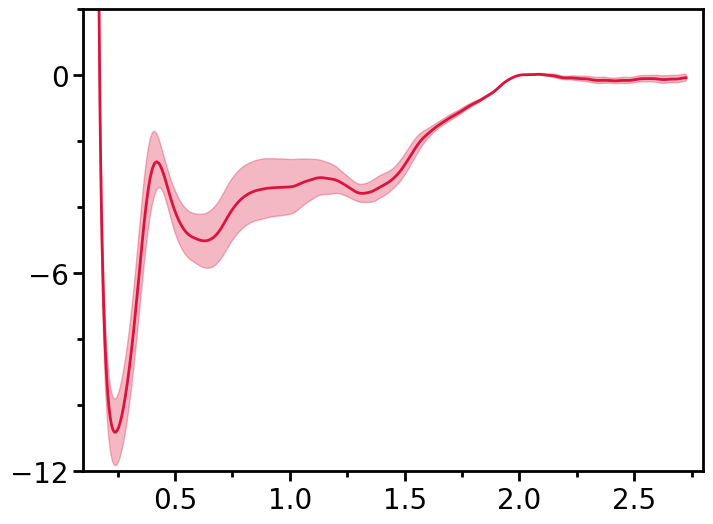

In [11]:
fig,ax = plt.subplots(1, figsize=(8,6))
ax.fill_between(cv, fmean-ferr, fmean+ferr, color='crimson', alpha=0.3)
ax.plot(cv, fmean, color='crimson', lw=2)
ax.set_xlim(0.1,2.8)
ax.set_xticks([0.5,1,1.5,2,2.5])
ax.set_ylim(-12,2)
ax.set_yticks([-12,-6,0])
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(3))
ax.tick_params(labelsize=20, length=7, width=2)
ax.tick_params(which='minor', length=4, width=2)
ax.spines[:].set_linewidth(2)
#
plt.savefig('saved_ana/fes.pdf')
plt.show()

In [16]:
uu = np.where((cv>=2.0) & (cv<=2.5))
uu = np.mean(fmean[uu]), np.mean(ferr[uu])
uu

(-0.07512423453374883, 0.06095603004502794)

In [17]:
bb = np.argmin(fmean)
bb = fmean[bb], ferr[bb]
bb

(-10.813337184659998, 1.013586745374635)

In [18]:
bb[0]-uu[0], bb[1]+uu[1]

(-10.738212950126249, 1.074542775419663)

#### -10.74 +- 1.07 kcal/mol

In [19]:
0.5922 * np.log(9e-9) # for 9 nM Kd

-10.971121633941156

In [20]:
0.599 * np.log(80e-9)  # for 80 nM kd

-9.788402282161245

##### standard state correction

In [109]:
# acute angle
0.55 / 1.57  * 90

31.52866242038217

tan(31.5) = height / base <br>
height (radius) = base * tan(31.5) <br>
radius = 20 * 0.6128 = 12.256 A <br><br>

In [125]:
# volume of funnel = volume of full cylineder + volume of cone
r_cyl = 1 # A
h_cyl = 40
#
r_cone = 12.256
h_cone = 20
#
vol = np.pi * r_cyl**2 * h_cyl  +  1/3 * np.pi * r_cone**2 * h_cone
vol

3271.6448714551357

In [132]:
1e27 / 6.022e23

1660.5778811026237

In [134]:
-0.5922 * np.log(3271.6/1660.6)

-0.40157092602327676

In [139]:
-10.74 - 0.4

-11.14

### pathways

In [23]:
def plot_pathway(ref, trj,
                 tstart, tend, tstep,
                 outfile,
                 lig='resname GDM and name C6 C20'):
    #
    aids = ['C1', 'C2']
    #
    ofile = open(outfile, 'w')
    for l in open(ref, 'r'):
        if 'ATOM ' in l[:6] and 'GDM' not in l:
            ofile.write(l)
            last = l
    ofile.write('TER \n')
    #
    items = last.strip().split()
    atom = int(items[1])+1   #for next entries
    resid = int(items[4])+1
    #
    u = mda.Universe(ref, trj)
    for t in range(tstart, tend+1, tstep):
        u.trajectory[t]
        pos = u.select_atoms(lig).positions
        for a,i in enumerate(pos):
            ofile.write(get_line(aids[a], atom, resid, i, 0))
            atom += 1
        resid += 1
        #
    ofile.close()


def get_line(aid, atom, resid, pos, beta):
    return f'HETATM {atom:04d} {aid}   ARR   {resid:03d}    {get_coord(pos[0])}{get_coord(pos[1])}{get_coord(pos[2])}  1.00  {beta:4.2f}          \n'

def get_coord(x):
    return (8-(len(f'{x:.3f}')))*' ' + f'{x:.3f}'

In [2]:
d = np.loadtxt('rmsds/r2.xvg', comments=['@','#'])

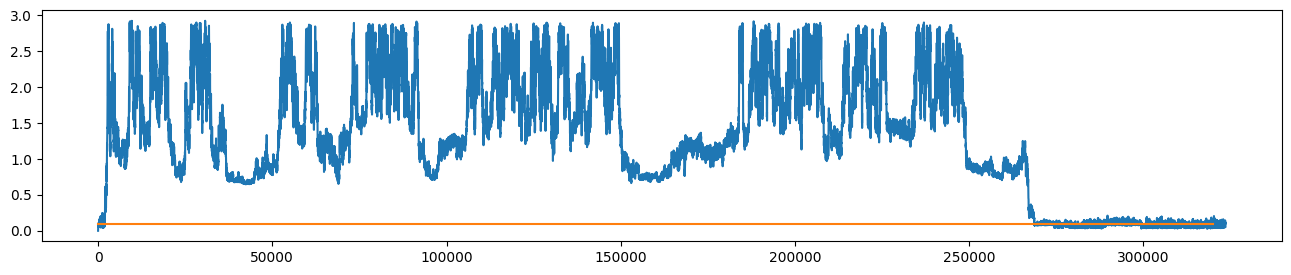

In [3]:
fig,ax=plt.subplots(1, figsize=(16,3))
ax.plot(*d.T)
ax.plot([0,320000],[0.1,0.1])
# ax.set_xlim(250000,300000)
# ax.set_ylim(0,1.1)

In [24]:
plot_pathway(ref='pbc_trjs/bound.pdb', trj='pbc_trjs/r2.xtc',
                 tstart=24500, tend=27000, tstep=10,
                 outfile='pathways/pathway2.pdb')

/home/msahil/softwares/miniconda3/envs/mda/lib/python3.9/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "


## Loop-in state

In [6]:
fes = [
    np.loadtxt(f'sum_fills/i{r}.dat')[:,1]
    for r in range(8)
]
cv = np.loadtxt('sum_fills/i0.dat')[:,0]

In [7]:
cv = pmodel(cv)
indi = np.argmin(np.abs(cv-2.0))
fes = [
    (f - f[indi]) * 0.24
    for f in fes
]

In [18]:
fmean = np.mean(fes, axis=0)
fstd = np.std(fes, axis=0)
ferr = fstd/(len(fes)-1)

In [25]:
bound_cv = 0.24, 0.04
int_cv = 0.51, 0.15

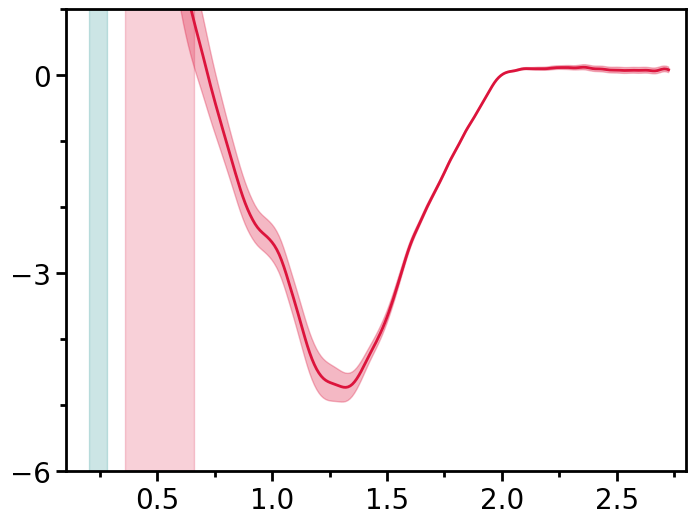

In [40]:
fig,ax = plt.subplots(1, figsize=(8,6))
#
ax.fill_between([bound_cv[0]-bound_cv[1], bound_cv[0]+bound_cv[1]], 
                [-6,-6], [1,1], color='teal', alpha=0.2
               )
ax.fill_between([int_cv[0]-int_cv[1], int_cv[0]+int_cv[1]], 
                [-6,-6], [1,1], color='crimson', alpha=0.2
               )
#
ax.fill_between(cv, fmean-ferr, fmean+ferr, color='crimson', alpha=0.3)
ax.plot(cv, fmean, color='crimson', lw=2)
ax.set_xlim(0.1,2.8)
ax.set_xticks([0.5,1,1.5,2,2.5])
ax.set_ylim(-6,1)
ax.set_yticks([-6,-3,0])
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(3))
ax.tick_params(labelsize=20, length=7, width=2)
ax.tick_params(which='minor', length=4, width=2)
ax.spines[:].set_linewidth(2)
#
plt.savefig('saved_ana/loopin_fes.pdf')
plt.show()

### CVs

In [2]:
rmsd = [
    np.loadtxt(f'rmsds/i{r}.xvg', comments=['@','#'])[:,1]
    for r in range(8)
]
cog = [
    np.loadtxt(f'bp_cog/i{r}.xvg', comments=['@','#'])[:,1]
    for r in range(8)
]
angle = [
    np.loadtxt(f'angle/i{r}.xvg', comments=['@','#'])[:,1]
    for r in range(8)
]
times = [
    np.loadtxt(f'bp_cog/i{r}.xvg', comments=['@','#'])[:,0]
    for r in range(8)
]

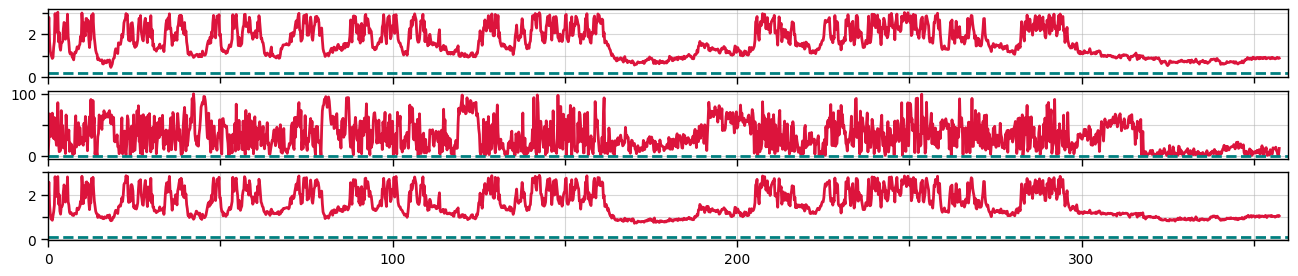

In [111]:
fig,ax = plt.subplots(3,1, figsize=(16,3), sharex=True)
r=7
skip=20
#
ax[0].plot(times[r][::skip]/1e3, cog[r][::skip], color='crimson', lw=2)
ax[0].hlines(0.2, 0,360, linestyle='--', color='teal', lw=2)
#
ax[1].plot(times[r][::skip]/1e3, np.abs(angle[r][::skip]-78), color='crimson', lw=2)
ax[1].hlines(0, 0,360, linestyle='--', color='teal', lw=2)
#
ax[2].plot(times[r][::skip]/1e3, rmsd[r][::skip], color='crimson', lw=2)
ax[2].hlines(0.1, 0,360, linestyle='--', color='teal', lw=2)
#
ax[0].set_xlim(0,360)
ax[0].set_xticks([0,100,200,300])
ax[0].set_yticks([0,2])
ax[1].set_yticks([0,100])
ax[2].set_yticks([0,2])
#
for a in ax: 
    a.grid(alpha=0.5, which='both')
    a.tick_params(labelsize=10, length=5, width=1)
    a.xaxis.set_minor_locator(AutoMinorLocator(2))
    a.yaxis.set_minor_locator(AutoMinorLocator(2))
    a.tick_params(which='minor', length=4, width=1)
    a.spines[:].set_linewidth(1)
#
plt.savefig(f'saved_ana/loopin_cvs{r}.pdf')
plt.show()